# Ant Colony Optimization 蚁群算法

## 本 Notebook 的教学目标

1. 在经典 TSP 场景下理解该算法的工作机制。
2. 完成一个从零实现版本，而不是只调用现成库。
3. 通过路径图、收敛曲线、统计结果观察算法行为。
4. 为下个月授课准备可直接展示的实验材料。

## 为什么选 TSP

蚁群算法与 TSP 的组合几乎是最经典的课堂案例，因为信息素矩阵和路径收敛过程都可以清楚地可视化。

TSP 的优点是：**结果是可视化路径，过程也是可视化路径**。因此它非常适合课堂讲解组合优化算法。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

# 统一图表风格，保证不同 Notebook 的视觉体验一致。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 为了让路径图更直观，这里统一生成二维城市坐标。

def make_cities(n_cities=20, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))


def pairwise_distances(cities):
    diff = cities[:, None, :] - cities[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def route_length(route, distance_matrix):
    rolled = np.roll(route, -1)
    return float(distance_matrix[route, rolled].sum())


def plot_route(cities, route, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ordered = cities[route]
    closed = np.vstack([ordered, ordered[0]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color='#1f77b4', lw=2, ms=6)
    for idx, (x, y) in enumerate(cities):
        ax.text(x + 1, y + 1, str(idx), fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return ax


def two_opt_swap(route, i, j):
    new_route = route.copy()
    new_route[i:j] = route[i:j][::-1]
    return new_route


def random_route(rng, n_cities):
    return rng.permutation(n_cities)


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# 固定城市坐标，保证不同算法 Notebook 之间有可比性。
cities = make_cities(n_cities=20, seed=11)
distance_matrix = pairwise_distances(cities)

## 算法直觉

核心思想：每只蚂蚁都会依据当前信息素和距离启发式构造路径；优秀路径会留下更多信息素，从而逐渐放大优质结构。

在讲课时，可以把这个算法与“纯贪心”或“纯随机搜索”对照起来讲，学生更容易抓住重点。

In [2]:
def construct_route(pheromone, distance_matrix, rng, alpha=1.0, beta=4.0):
    n_cities = len(distance_matrix)
    start = rng.integers(0, n_cities)
    route = [start]
    unvisited = set(range(n_cities)) - {start}

    while unvisited:
        current = route[-1]
        candidates = np.array(list(unvisited))
        tau = pheromone[current, candidates] ** alpha
        eta = (1.0 / np.maximum(distance_matrix[current, candidates], 1e-9)) ** beta
        probabilities = tau * eta
        probabilities = probabilities / probabilities.sum()
        next_city = rng.choice(candidates, p=probabilities)
        route.append(int(next_city))
        unvisited.remove(int(next_city))

    return np.array(route, dtype=int)


def ant_colony_optimization(distance_matrix, n_ants=24, n_iterations=120, alpha=1.0, beta=4.0, evaporation=0.4, q=150, seed=0):
    rng = np.random.default_rng(seed)
    n_cities = len(distance_matrix)
    pheromone = np.ones((n_cities, n_cities), dtype=float)

    best_route = None
    best_length = np.inf
    best_lengths = []
    route_snapshots = []
    pheromone_snapshots = []

    for iteration in range(1, n_iterations + 1):
        routes = []
        lengths = []
        for _ in range(n_ants):
            route = construct_route(pheromone, distance_matrix, rng, alpha=alpha, beta=beta)
            length = route_length(route, distance_matrix)
            routes.append(route)
            lengths.append(length)

            if length < best_length:
                best_route = route.copy()
                best_length = length

        lengths = np.array(lengths)

        # 信息素先蒸发，再由本轮所有蚂蚁按路径质量补充。
        pheromone *= (1 - evaporation)
        for route, length in zip(routes, lengths):
            deposit = q / length
            for i in range(len(route)):
                a = route[i]
                b = route[(i + 1) % len(route)]
                pheromone[a, b] += deposit
                pheromone[b, a] += deposit

        best_lengths.append(float(best_length))
        if iteration in {1, 5, 20, 50, 120}:
            route_snapshots.append((iteration, best_route.copy()))
            pheromone_snapshots.append((iteration, pheromone.copy()))

    return {
        'best_route': best_route,
        'best_length': float(best_length),
        'best_lengths': np.array(best_lengths),
        'route_snapshots': route_snapshots,
        'pheromone_snapshots': pheromone_snapshots,
    }

## 单次实验演示

下面先做一次完整实验。建议课堂上先关注：

1. 初始路径和最终路径差别有多大。
2. 收敛过程中是否存在明显跳跃。
3. 算法是否会在早期快速改进、后期缓慢收敛。

best route length: 377.111


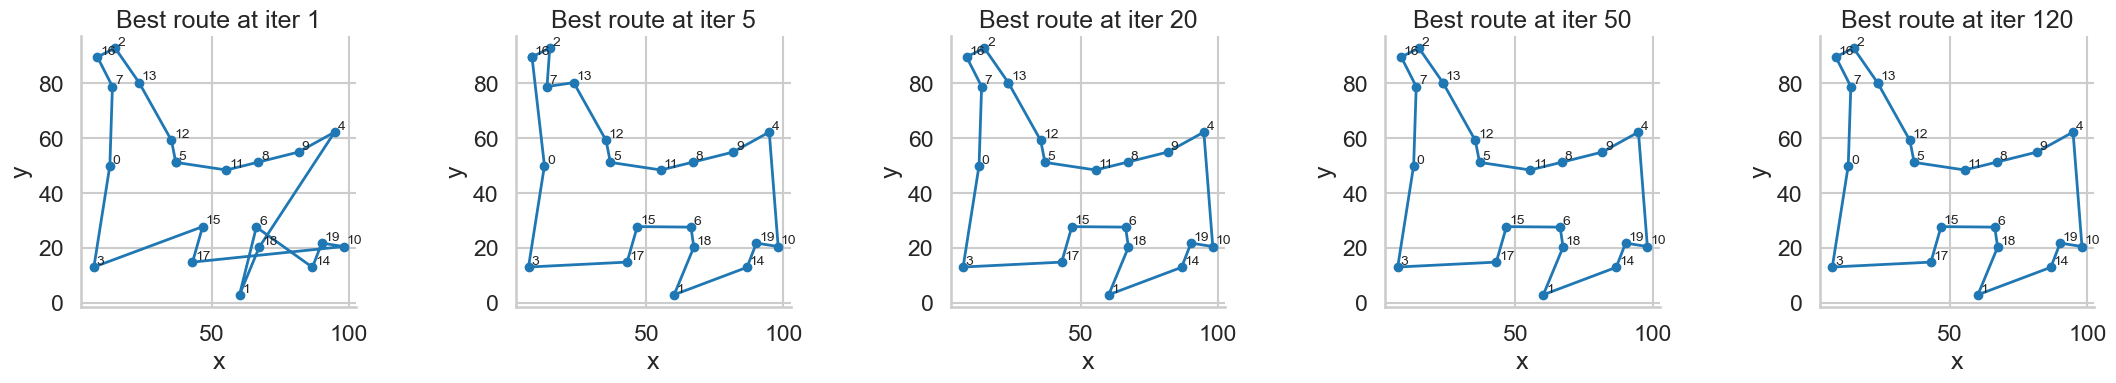

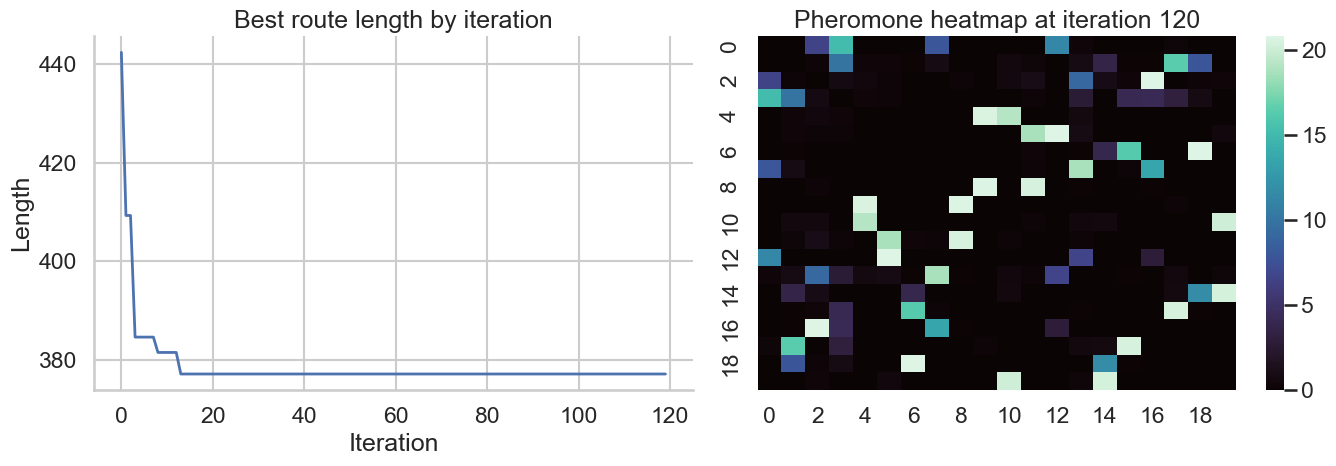

<Figure size 700x700 with 0 Axes>

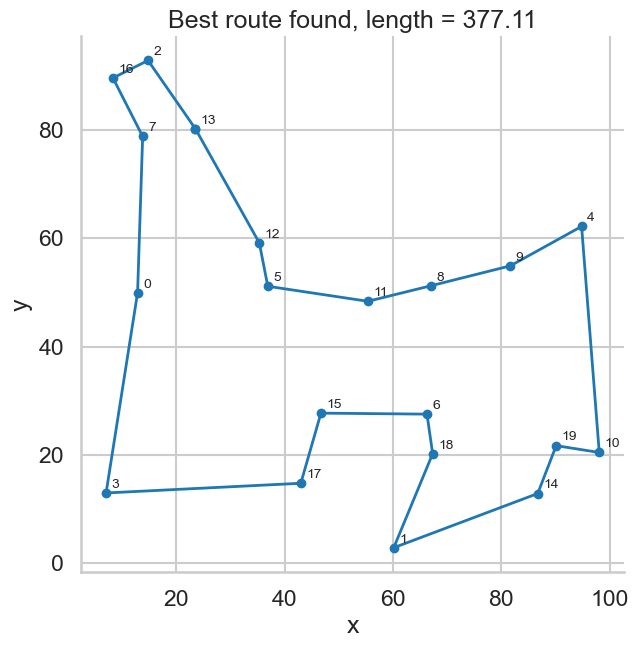

In [3]:
aco_result = ant_colony_optimization(distance_matrix, seed=4)
print('best route length:', round(aco_result['best_length'], 3))

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (iteration, route) in zip(axes, aco_result['route_snapshots']):
    plot_route(cities, route, f'Best route at iter {iteration}', ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(aco_result['best_lengths'], lw=2)
axes[0].set_title('Best route length by iteration')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Length')

final_iteration, final_pheromone = aco_result['pheromone_snapshots'][-1]
sns.heatmap(final_pheromone, cmap='mako', ax=axes[1])
axes[1].set_title(f'Pheromone heatmap at iteration {final_iteration}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plot_route(cities, aco_result['best_route'], f'Best route found, length = {aco_result["best_length"]:.2f}')
plt.show()

## 多次运行与参数分析

组合优化算法往往带有随机性，因此只看一次结果不够。这里用多次实验和参数敏感性分析来说明算法的稳定性与可调节性。

,ACO statistics
best,3.771107e+02
mean,3.771107e+02
worst,3.771107e+02
std,1.136868e-13


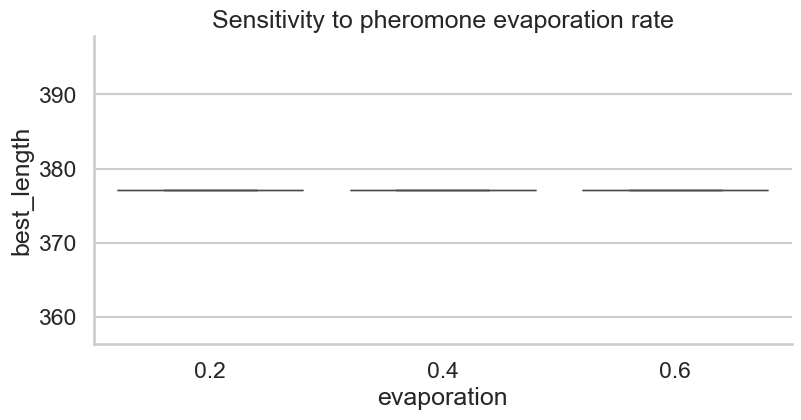

In [4]:
run_scores = [ant_colony_optimization(distance_matrix, seed=seed)['best_length'] for seed in range(15)]
display(summarize_runs(run_scores).to_frame(name='ACO statistics'))

evaporation_values = [0.2, 0.4, 0.6]
records = []
for evaporation in evaporation_values:
    for seed in range(8):
        best_length = ant_colony_optimization(distance_matrix, evaporation=evaporation, seed=seed)['best_length']
        records.append({'evaporation': evaporation, 'best_length': best_length})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='evaporation', y='best_length')
plt.title('Sensitivity to pheromone evaporation rate')
plt.show()

## 课堂总结

讲这一类 TSP 实验时，可以让学生反复回答三个问题：

1. 新路径是怎样产生的。
2. 更差的路径何时会被接受，或为什么永远不被接受。
3. 算法如何在“探索新结构”和“保留好结构”之间权衡。